In [1]:
using HyQMOM, Plots, CSV, Tables, LaTeXStrings

In [41]:
# M4_file = "../out/VlasovPoisson/VlasovPoisson_moments_T25.0_M5_k0.5_ϵ0.001_p1_level8.tsv"
M_vector = [4, 5, 6, 7];#!, 7, 8,] # number of moments

In [42]:
L2_history_dict = Dict{Int, Vector{Float64}}()
for M in M_vector
    file = "../out/VlasovPoisson/VlasovPoisson_moments_T25.0_M$(M)_k0.5_ϵ0.001_p1_level8.tsv"
    sol = readsol(file)  # load solution from file

    x = Vector{Float64}
    u_solutions = Matrix{Float64}  # (vars × npts) matrix per dataset
    time = LinRange(0, 25.0, length(sol))  # time vector # ! hard-coded atm

    final_block = sol[end]               # last time level
    x = final_block[:, 1]                   # x coordinates (npts)
    L2_history = []
    for block in sol
        ρ = block[:, 2]               # density (npts)
        E = HyQMOM.solve_poisson_periodic_fft(ρ, (x[1], x[end]))  # electric field (npts)
        E_L2 = (sum(E.^2) * (x[end] - x[1]) / length(x))^(1/2)
        push!(L2_history, E_L2)
    end
    L2_history_dict[M] = L2_history
end

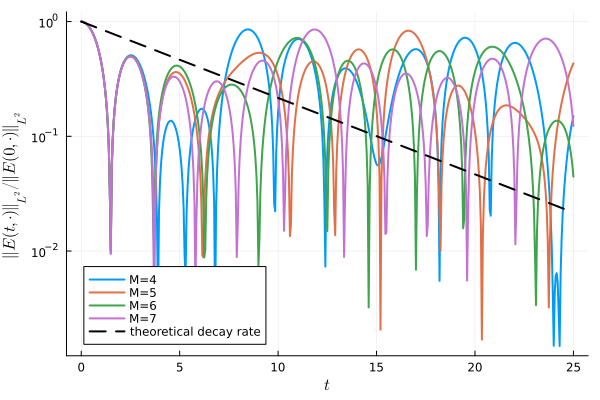

In [45]:
p = plot()
for M in M_vector
    plot!(p, 
        time, L2_history_dict[M] ./ L2_history_dict[M][1], 
        label="M=$(M)", lw=2
    ) 
end
γ = 0.1533  # theoretical damping rate
plot!(
    p, 
    time, exp.(-γ * time), 
    label="theoretical decay rate", 
    lw=2, ls=:dash, 
    color=:black
)
xlabel!(p, L"$t$")
ylabel!(p, L"∥E(t,⋅)∥_{L^2} / ∥E(0,⋅)∥_{L^2}")
yaxis!(p, :log10)
plot!(p, legend=:bottomleft)
display(p)